# **The AI Layoff Revolution: A Seven-Year Analysis (2020-2026)**
**Data Analysis Report**

March 2026

Prepared by **Vinh NGUYEN Phuc (Ivan)**

## I. Objectives and Research Questions

### 1.1 Objectives

This report analyzes tech layoffs from 2020 to 2026 to examine:
- The main drivers of layoffs
- The departments most affected
- The role of AI in restructuring
- Geographic patterns
- Short-term market reaction

The report concludes with key findings and practical implications.

### 1.2 Research Questions

1. How have tech layoffs evolved from 2020 to 2026?

   Goal: identify the trend over time.

2. Which companies have laid off the most employees?

   Goal: identify the firms responsible for the largest workforce reductions.

3. Which industries are most affected by layoffs?

   Goal: understand which sectors are most vulnerable.

4. Which countries experience the highest number of layoffs?

   Goal: analyze geographic impact.

5. What are the most common reasons for layoffs?

   Goal: identify the main drivers behind workforce reductions.

6. Are layoffs increasing in AI-related companies?

   Goal: examine the relationship between AI adoption and layoffs.

7. Which company sizes tend to lay off more employees?

   Goal: compare startups, mid-sized firms, and large corporations.

8. Which departments are most frequently affected?

   Goal: identify the roles most vulnerable to layoffs.

9. Is there a relationship between layoffs and stock price changes?

   Goal: test whether layoffs influence short-term market perception.

## II. Data Loading and Initial Inspection

### Dataset and Scope

This analysis uses the file `global_ai_tech_layoffs_2020_2026.csv`, which contains layoff events from 2020 to 2026 across companies, industries, countries, and related business attributes. The dataset supports both descriptive analysis and simple correlation-based exploration, but it should be interpreted as event-level data rather than a complete census of all layoffs worldwide.

In [ ]:
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up data visualization style
# Using 'whitegrid' helps with clear alignment and comparing data points
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# Load the dataset
df = pd.read_csv('global_ai_tech_layoffs_2020_2026.csv')

# Display the first 10 rows to verify the data
display(df.head(10))

,event_id,company,industry,hq_country,hq_city,continent,founded_year,company_size_est,company_status,date_announced,...,quarter,number_laid_off,percentage_of_workforce,departments_affected,primary_reason,impact_scope,severance_info,source,stock_price_change_1wk_pct,is_ai_related_layoff
0,LO-1034,Swiggy,Food Delivery,India,Bangalore,Asia,2014,6000,Private,2020-01-04,...,Q1,722,12.0,HR / People; Legal; Product,Post-Pandemic Overhiring Correction,Global,Varies by region,News Report - The Verge,NaN,False
1,LO-1020,Oracle,Enterprise Software,United States,Austin,North America,1977,164000,Public,2020-01-06,...,Q1,6189,3.8,Legal; Business Development; Data Science / AI...,Investor Pressure,Global,6 months base salary,News Report - Bloomberg,-1.30,False
2,LO-1051,Tesla,Electric Vehicles / AI,United States,Austin,North America,2003,140000,Public,2020-01-08,...,Q1,9512,6.8,Operations,Product Shutdown,Multiple Regions,6 months base salary,News Report - CNBC,-3.89,False
3,LO-1063,Anthropic,Artificial Intelligence,United States,San Francisco,North America,2021,1500,Private,2020-01-09,...,Q1,132,8.8,Marketing; Sales; Research; Customer Support,AI Automation Replacing Roles,United States,Varies by region,Company Press Release,NaN,True
4,LO-1139,Alibaba,E-Commerce / Cloud,China,Hangzhou,Asia,1999,220000,Public,2020-01-11,...,Q1,16245,7.4,Recruiting; Supply Chain; Legal; Engineering,Merger / Acquisition,China,4 weeks base salary,News Report - TechCrunch,-5.16,False
5,LO-1026,BioNTech,Biotech / AI,Germany,Mainz,Europe,2008,6000,Public,2020-01-22,...,Q1,368,6.1,Marketing; Operations; Legal,Post-Pandemic Overhiring Correction,Germany,3 months base salary,Regulatory Filing,2.57,False
6,LO-1096,Wise,Fintech,United Kingdom,London,Europe,2011,5500,Public,2020-01-23,...,Q1,290,5.3,Business Development; Customer Support; Conten...,Shift to AI-First Strategy,United Kingdom,12 weeks base salary,Employee Reports (Blind/Glassdoor),-9.03,True
7,LO-1177,Anthropic,Artificial Intelligence,United States,San Francisco,North America,2021,1500,Private,2020-01-24,...,Q1,65,4.3,Finance; HR / People; Research,Regulatory Pressure,Global,12 weeks base salary,News Report - TechCrunch,NaN,False
8,LO-1000,Stripe,Fintech,United States,San Francisco,North America,2010,8000,Private,2020-01-24,...,Q1,398,5.0,Operations; Marketing,AI Automation Replacing Roles,Global,Varies by region,News Report - The Verge,NaN,True
9,LO-1002,Wise,Fintech,United Kingdom,London,Europe,2011,5500,Public,2020-01-25,...,Q1,696,12.7,Design; Legal; Operations; Marketing,Duplicate Roles After Merger,Global,3 months base salary,SEC Filing,-4.10,False


## III. Data Cleaning and Preprocessing

### 3.1 Dataset Overview


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1850 entries, 0 to 1849
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   event_id                    1850 non-null   str    
 1   company                     1850 non-null   str    
 2   industry                    1850 non-null   str    
 3   hq_country                  1850 non-null   str    
 4   hq_city                     1850 non-null   str    
 5   continent                   1850 non-null   str    
 6   founded_year                1850 non-null   int64  
 7   company_size_est            1850 non-null   int64  
 8   company_status              1850 non-null   str    
 9   date_announced              1850 non-null   str    
 10  year                        1850 non-null   int64  
 11  month                       1850 non-null   int64  
 12  quarter                     1850 non-null   str    
 13  number_laid_off             1850 non-null   

### 3.2 Missing Values

In [7]:
#Check missing value
df.isnull().sum()

event_id                        0
company                         0
industry                        0
hq_country                      0
hq_city                         0
continent                       0
founded_year                    0
company_size_est                0
company_status                  0
date_announced                  0
year                            0
month                           0
quarter                         0
number_laid_off                 0
percentage_of_workforce         0
departments_affected            0
primary_reason                  0
impact_scope                    0
severance_info                  0
source                          0
stock_price_change_1wk_pct    461
is_ai_related_layoff            0
dtype: int64

Note: `stock_price_change_1wk_pct` is missing only for private companies. Because these firms are not publicly listed, they do not have observable stock prices. The missing values are therefore expected and do not indicate a data quality problem.

In [8]:
df['company_status'].value_counts()

company_status
Public     1389
Private     461
Name: count, dtype: int64

The missing values belong entirely to Private companies.
Since Private companies are not listed on the stock exchange, they do not have stock prices. Therefore, the missing values in stock_price_change_1wk_pct are expected and not considered data quality issues.

### 3.3 Data Type Conversion


In [9]:
df['is_ai_related_layoff'] = df['is_ai_related_layoff'].astype(int)

### 3.4 Date Parsing


In [10]:
# Convert to datetime format for easier Time Series analysis
df['date_announced'] = pd.to_datetime(df['date_announced'])

### 3.5 Encoding Categorical Variables

Label encoding is used here to prepare categorical fields for correlation analysis and other numeric summaries.

In [11]:
from sklearn.preprocessing import LabelEncoder

# Country encoding
le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['hq_country'])

# Company status
df['company_status_encoded'] = df['company_status'].map({'Private': 0, 'Public': 1})

# Continent encoding
le_continent = LabelEncoder()
df['continent_encoded'] = le_continent.fit_transform(df['continent'])


### 3.6 Feature Engineering

We derive layoff intensity to normalize layoffs by company size and make cross-company comparisons more meaningful.

In [12]:
df['layoff_intensity'] = df['number_laid_off'] / df['company_size_est']


## IV. Exploratory Data Analysis

In [13]:
# General descriptive statistics
print("--- Descriptive Statistics for Numeric Data ---")
display(df[['number_laid_off', 'percentage_of_workforce', 'company_size_est']].describe().round(2))

# Total number of employees laid off per year
layoffs_by_year = df.groupby('year')['number_laid_off'].sum().reset_index()

# Percentage of layoff events related to AI (e.g., AI-First Strategy, Automation)
ai_impact_pct = df['is_ai_related_layoff'].value_counts(normalize=True) * 100

print("\n--- Proportion of AI-Related Layoff Events ---")
print(ai_impact_pct.round(2).astype(str) + '%')

--- Descriptive Statistics for Numeric Data ---


,number_laid_off,percentage_of_workforce,company_size_est
count,1850.00,1850.00,1850.00
mean,4452.67,6.05,76510.09
std,12196.35,4.31,185244.20
min,10.00,0.30,80.00
25%,197.25,2.80,5000.00
50%,657.50,4.90,11000.00
75%,3862.00,8.20,84900.00
max,205254.00,25.50,1540000.00



--- Proportion of AI-Related Layoff Events ---
is_ai_related_layoff
0    79.46%
1    20.54%
Name: proportion, dtype: str


## V. Data Visualization and Interpretation

### 5.1 Correlation Heatmap

This section checks the linear relationships among the main numeric variables in the dataset.

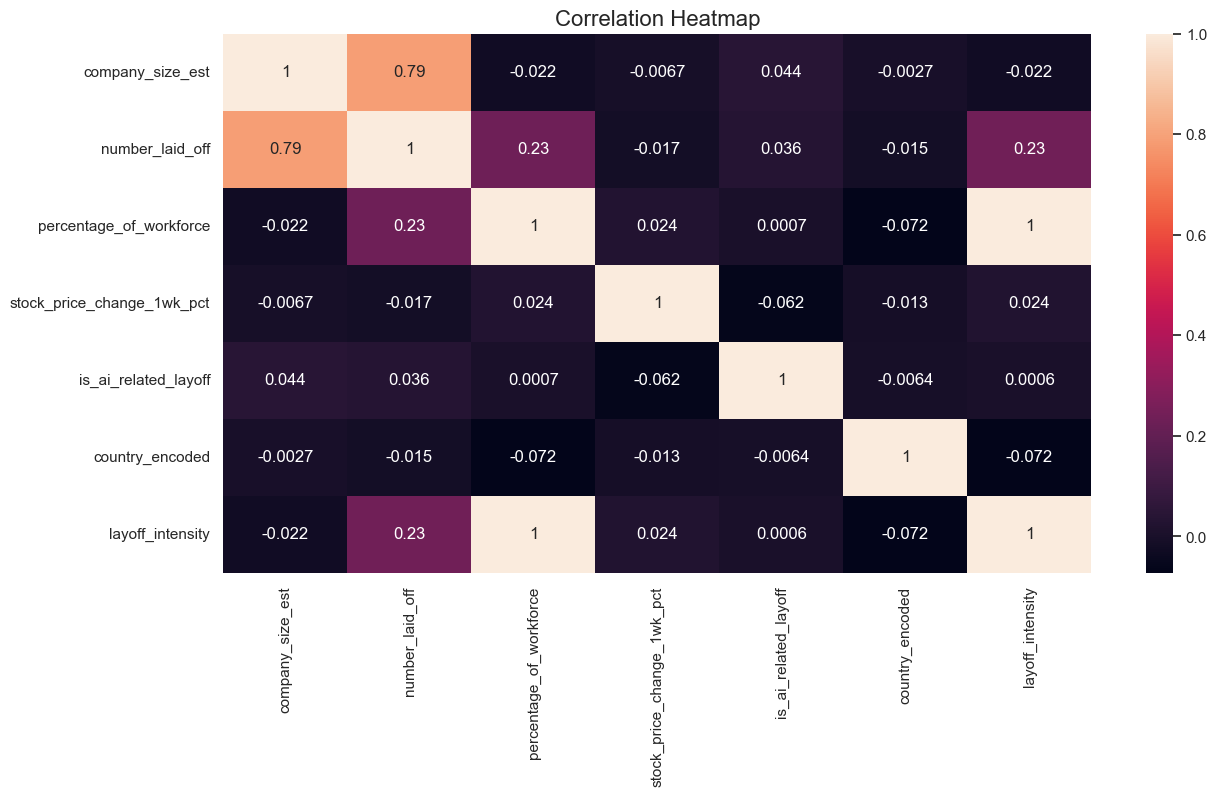

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'company_size_est',
    'number_laid_off',
    'percentage_of_workforce',
    'stock_price_change_1wk_pct',
    'is_ai_related_layoff',
    'country_encoded',
    'layoff_intensity'
]

corr_matrix = df[features].corr()

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()


The correlation matrix suggests that most relationships are modest. Company size has the clearest positive relationship with layoff volume, while short-term stock price changes show only a very weak connection to layoffs. AI-related layoffs do not show a strong linear pattern in this view, which suggests that multiple factors are shaping workforce reductions rather than a single dominant driver.

### 5.2 Company Size and Layoff Volume

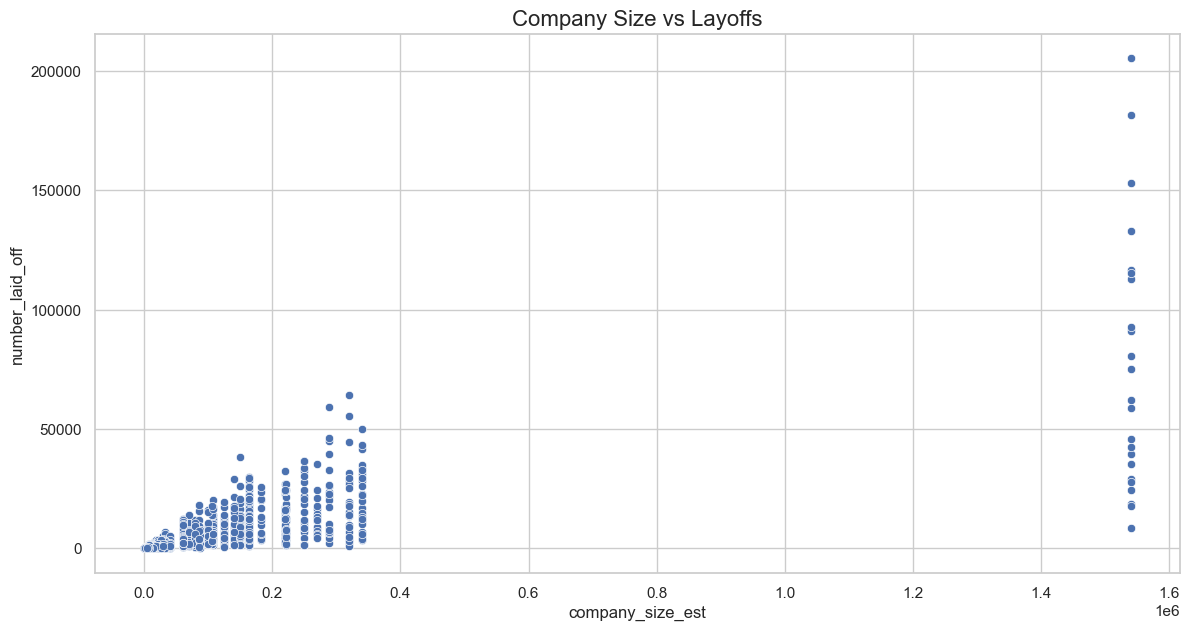

In [12]:
sns.scatterplot(data=df, x='company_size_est', y='number_laid_off')
plt.title("Company Size vs Layoffs")
plt.show()

Larger companies generally lay off more employees in absolute terms. The relationship is positive but not perfectly linear, which suggests that firm size influences layoff volume, but strategic decisions and business conditions also matter.

### 5.3 Layoff Trends Over Time

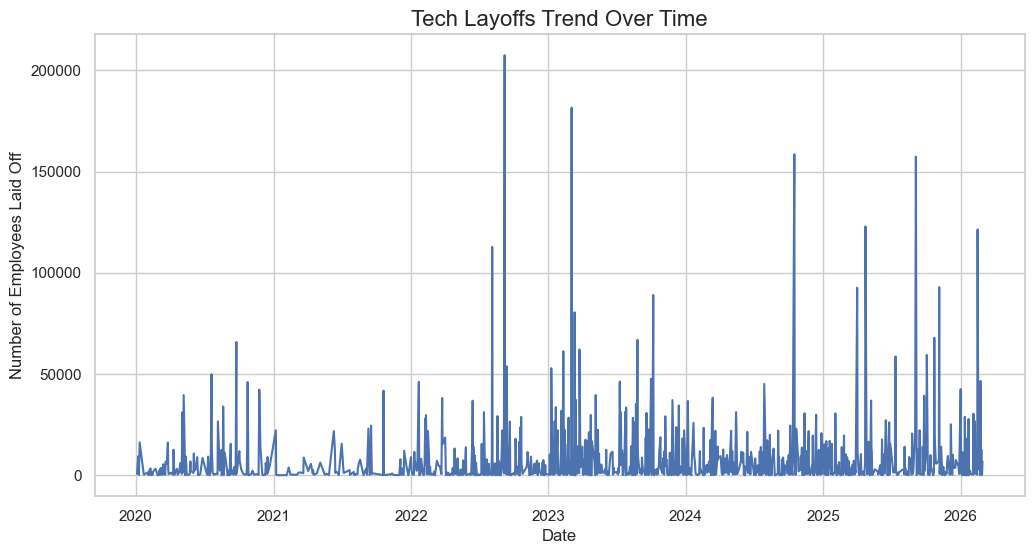

In [21]:
import matplotlib.pyplot as plt

monthly_layoffs = df.groupby("date_announced")["number_laid_off"].sum()

plt.figure(figsize=(12,6))
plt.plot(monthly_layoffs)

plt.title("Tech Layoffs Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Employees Laid Off")

plt.show()

Layoff volume rises sharply after 2022, which is consistent with post-pandemic correction and broader macroeconomic tightening.

### 5.4 Top Companies by Layoffs

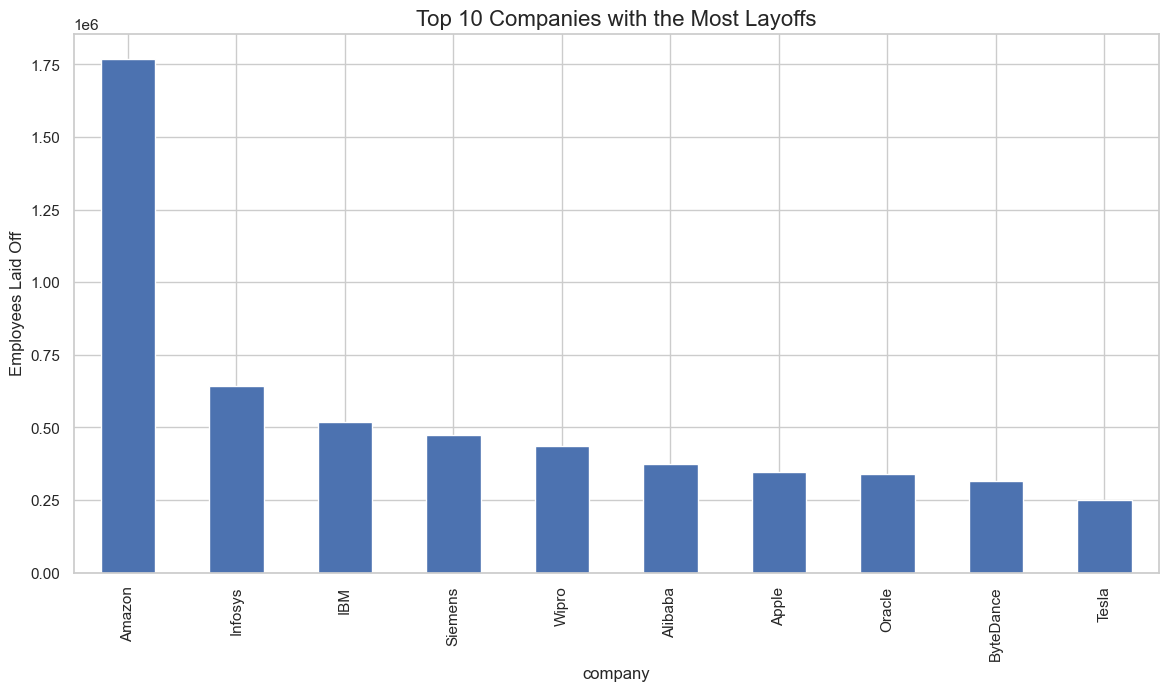

In [14]:
top_companies = df.groupby("company")["number_laid_off"].sum().nlargest(10)

top_companies.plot(kind="bar")
plt.title("Top 10 Companies with the Most Layoffs")
plt.ylabel("Employees Laid Off")
plt.show()

Layoff activity is concentrated among a small number of large technology firms, with Amazon standing out as an outlier. This concentration suggests that the largest employers also carry the largest restructuring footprint.

### 5.5 Layoffs by Industry

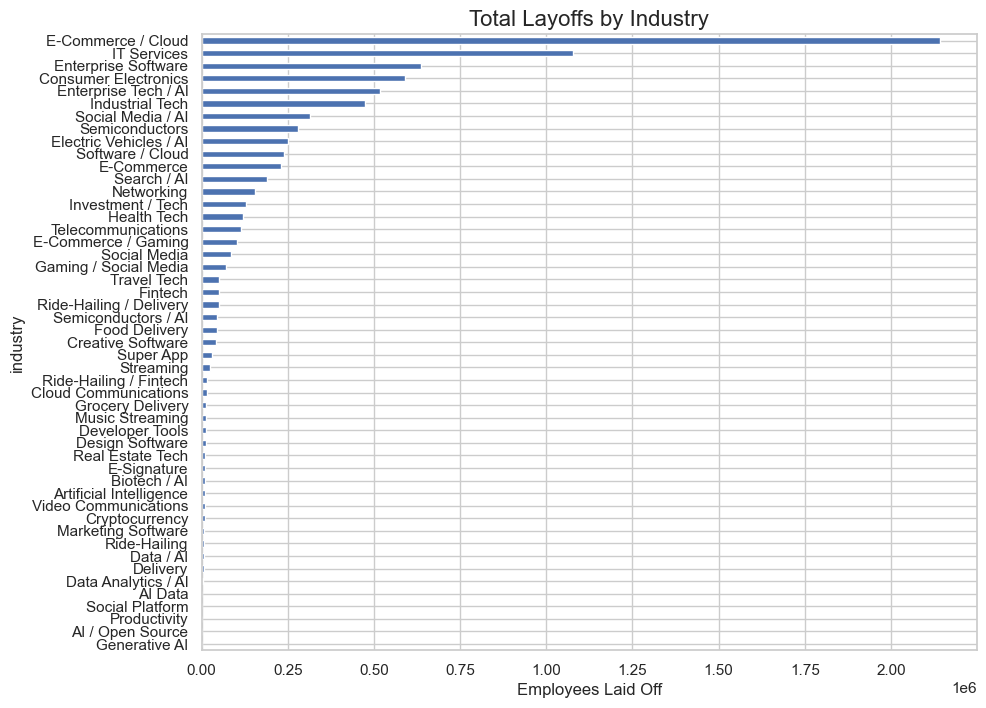

In [22]:
industry_layoffs = df.groupby("industry")["number_laid_off"].sum().sort_values()

plt.figure(figsize=(10,8))
industry_layoffs.plot(kind="barh")

plt.title("Total Layoffs by Industry")
plt.xlabel("Employees Laid Off")

plt.show()

Fintech, e-commerce, and software are the most affected industries. These sectors appear more exposed to rapid market changes, cost pressure, and restructuring tied to growth slowdown.

### 5.6 Departments Most Affected

In [17]:
# === PARSE DEPARTMENTS ===
df['departments_list'] = df['departments_affected'].astype(str).apply(
    lambda x: [d.strip() for d in x.split(';') if d.strip()]
)

# Flatten all departments
all_depts = [dept for sublist in df['departments_list'] for dept in sublist]

# Split by AI vs Non-AI
ai_df = df[df['is_ai_related_layoff'] == True]
non_ai_df = df[df['is_ai_related_layoff'] == False]

ai_depts = [dept for sublist in ai_df['departments_list'] for dept in sublist]
non_ai_depts = [dept for sublist in non_ai_df['departments_list'] for dept in sublist]

# Count frequency
ai_count = Counter(ai_depts)
non_ai_count = Counter(non_ai_depts)

# Top 10
ai_top = pd.DataFrame(ai_count.most_common(10), columns=['Department', 'Count'])
non_ai_top = pd.DataFrame(non_ai_count.most_common(10), columns=['Department', 'Count'])

print("AI-Related Top Departments:\n", ai_top)
print("\nNon-AI Top Departments:\n", non_ai_top)

AI-Related Top Departments:
              Department  Count
0             Marketing     62
1           Engineering     57
2        Trust & Safety     57
3                 Sales     55
4              Research     55
5      Customer Support     55
6           HR / People     55
7                 Legal     55
8  Business Development     54
9               Product     54

Non-AI Top Departments:
              Department  Count
0          Supply Chain    230
1            Operations    225
2               Finance    222
3              Research    220
4  Business Development    218
5      Customer Support    215
6                 Sales    213
7                Design    212
8             Marketing    210
9            Recruiting    202


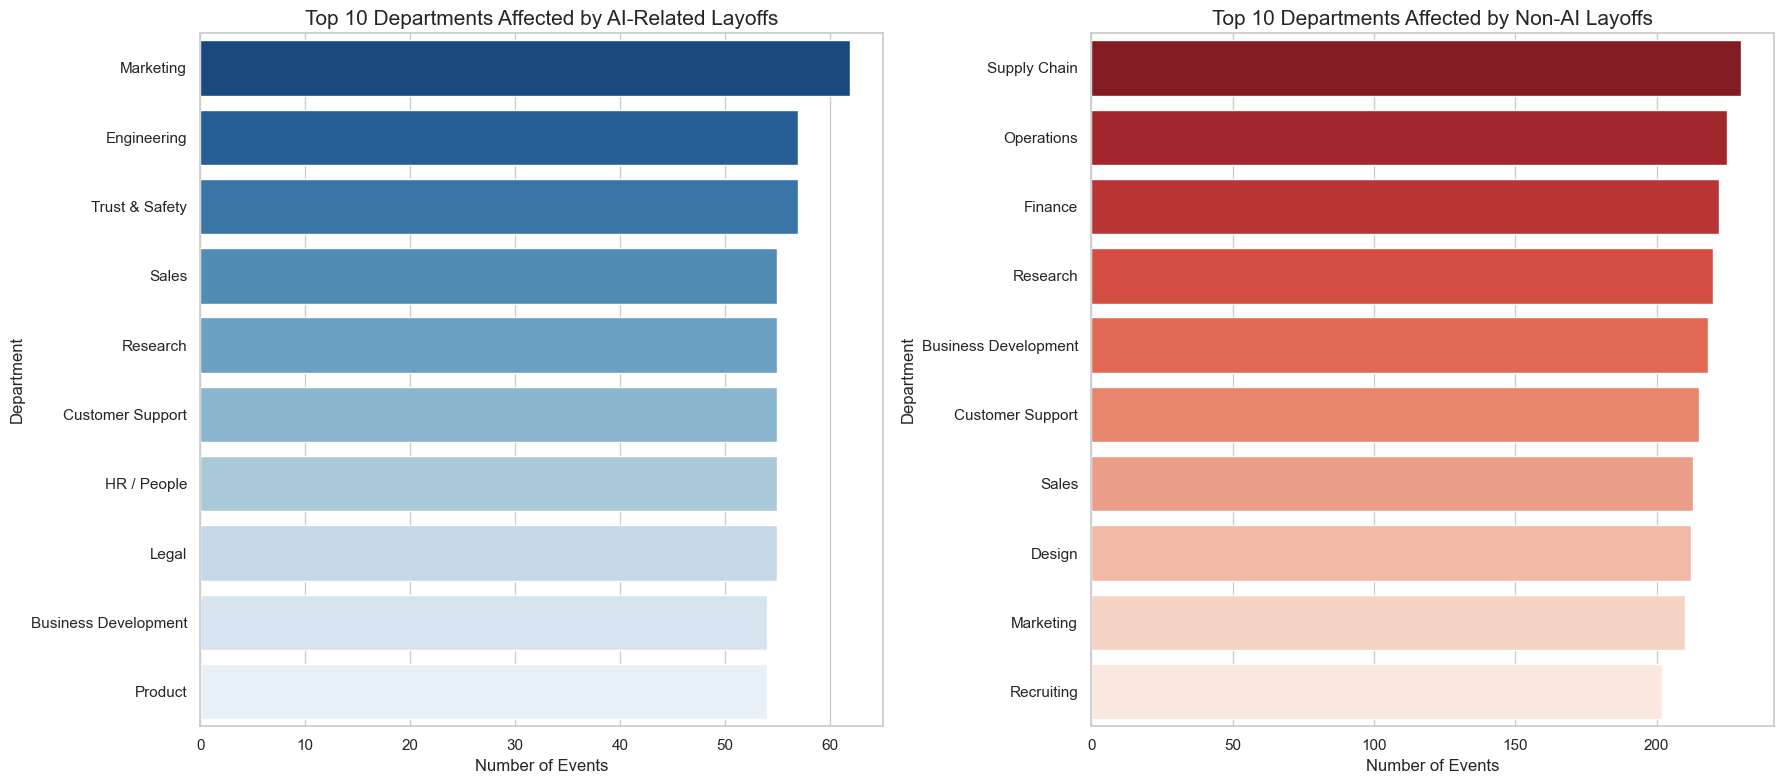

In [18]:
# === VISUALIZATION: Top Departments Comparison ===
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# AI-Related
sns.barplot(data=ai_top, y='Department', x='Count', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Departments Affected by AI-Related Layoffs', fontsize=15)
axes[0].set_xlabel('Number of Events')

# Non-AI
sns.barplot(data=non_ai_top, y='Department', x='Count', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Departments Affected by Non-AI Layoffs', fontsize=15)
axes[1].set_xlabel('Number of Events')

plt.tight_layout()
plt.show()

AI-related layoffs are concentrated in research, AI engineering, product, core engineering, customer support, marketing, and data science. This pattern suggests structural transformation, where companies reduce or redesign knowledge-intensive work as AI capabilities expand.

Non-AI layoffs are more traditional and are concentrated in operations, HR and recruiting, legal, sales, and supply chain. These reductions are more consistent with cost-cutting, efficiency improvements, and post-pandemic adjustment.

### 5.7 Layoffs by Country

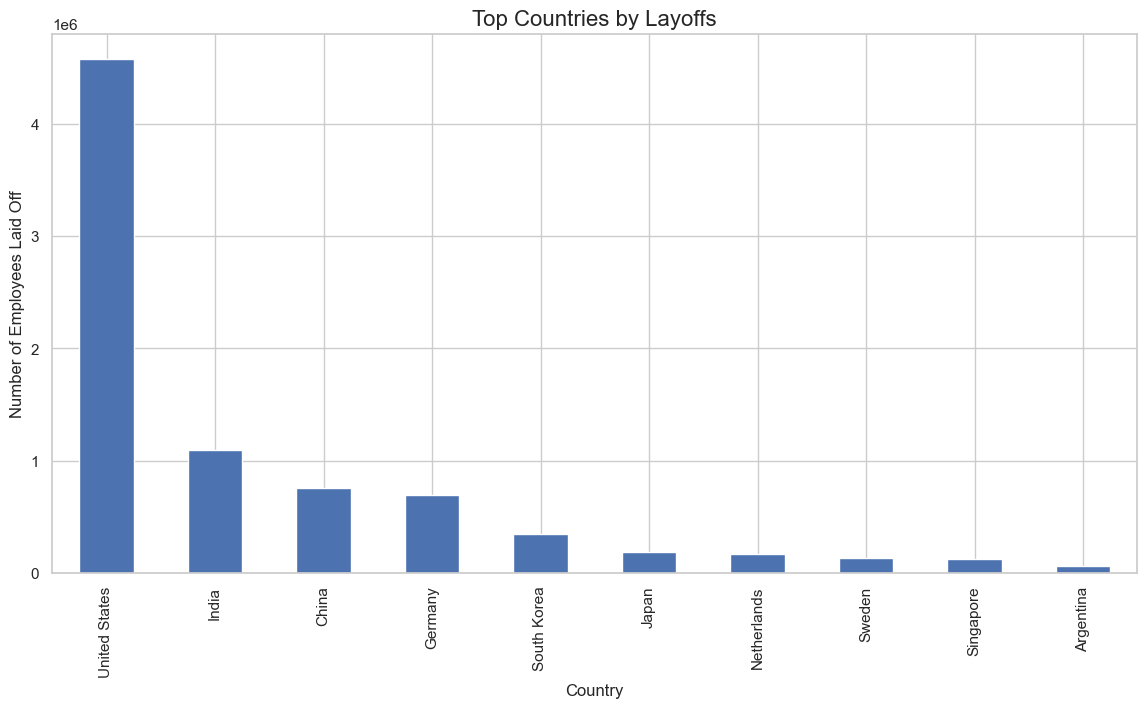

In [ ]:
country_layoffs = df.groupby("hq_country")["number_laid_off"].sum().nlargest(10)

country_layoffs.plot(kind="bar")
plt.title("Top Countries by Layoffs")
plt.xlabel("Country")
plt.ylabel("Number of Employees Laid Off")
plt.show()

The United States dominates global tech layoffs, which reflects its central role in the tech industry and the concentration of major technology employers there.

### 5.8 Layoff Reasons

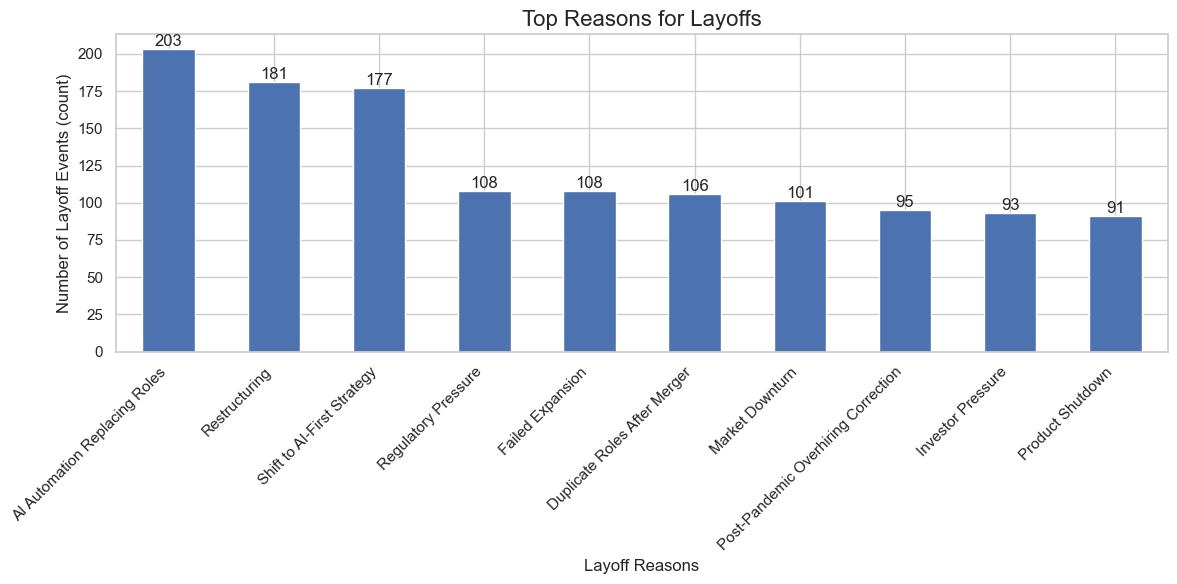

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

ax = df["primary_reason"].value_counts().head(10).plot(kind="bar")

plt.title("Top Reasons for Layoffs")
plt.xlabel("Layoff Reasons")
plt.ylabel("Number of Layoff Events (count)")

plt.xticks(rotation=45, ha="right")

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

AI-driven transformation and organizational restructuring are the most common layoff reasons. This indicates that many workforce reductions are tied to automation, efficiency gains, and strategic realignment rather than isolated cost shocks.

### 5.9 Layoffs and Short-Term Stock Performance

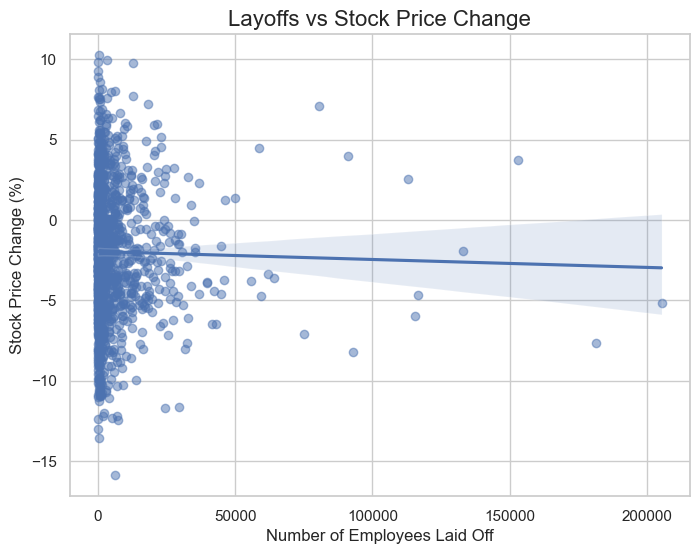

In [20]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.regplot(
    x="number_laid_off",
    y="stock_price_change_1wk_pct",
    data=df,
    scatter_kws={'alpha':0.5}
)

plt.title("Layoffs vs Stock Price Change")
plt.xlabel("Number of Employees Laid Off")
plt.ylabel("Stock Price Change (%)")

plt.show()

There is no clear relationship between layoff size and one-week stock price changes. In the short run, investors appear to respond to broader growth, revenue, and strategy signals rather than layoffs alone.

## VI. Key Findings and Implications

**1. How have tech layoffs evolved from 2020 to 2026?**

Layoffs increased sharply after 2022, suggesting a post-pandemic correction and a shift toward tighter cost control.

**2. Which companies have laid off the most employees?**

The largest layoffs are concentrated in major global technology firms. Larger organizations have more room to restructure, but they also carry greater workforce exposure.

Implications:
- Large companies should avoid aggressive over-hiring during growth periods.
- Workforce planning should be gradual and data-driven.
- Phased restructuring is often less disruptive than sudden mass layoffs.

**3. Which industries are most affected by layoffs?**

Fintech, software, and e-commerce are the most affected sectors.

Implications:
- Job risk increases in sectors with fast market shifts and margin pressure.
- Skill diversification becomes more important during downturns.
- AI and data skills can improve resilience.

**4. Which countries experience the highest number of layoffs?**

The United States accounts for the largest share of layoffs, reflecting its dominant role in the global tech industry.

**5. What are the most common reasons for layoffs?**

AI-driven transformation, organizational restructuring, and strategic adjustment are the main drivers of layoffs.

Implications:
- AI adoption is changing skill requirements.
- Companies should prioritize reskilling over layoffs where possible.
- Long-term planning is more effective than reactive cost-cutting.

**6. Are layoffs increasing in AI-related companies?**

AI-related restructuring is becoming more common, indicating a broader shift toward automation and AI adoption.

Implications:
- AI investments should be paired with workforce upskilling.
- Sudden AI-driven layoffs can create unnecessary disruption.
- Gradual adoption is more sustainable than abrupt transitions.

**7. Which company sizes tend to lay off more employees?**

There is a strong relationship between company size and layoff volume. Large organizations face higher restructuring risk because they employ more people and operate at greater scale.

Implications:
- Workforce forecasting should begin before hiring slows.
- Internal reskilling can reduce the need for large-scale layoffs.
- Hiring freezes may be preferable to abrupt cuts.

**8. Which departments are most frequently affected?**

HR, marketing, operations, and other support functions are frequently affected.

Implications:
- Companies should improve internal communication during restructuring.
- HR can shift toward workforce planning and talent redeployment.
- Internal mobility programs can reduce disruption costs.

**9. Is there any relationship between layoffs and stock price changes?**

There is no clear relationship between layoffs and short-term stock price changes.

Implications:
- Layoffs should not be used as a strategy to boost stock price.
- Investors appear to value long-term growth, innovation, and revenue performance more than workforce reductions.

Overall, the evidence suggests that layoffs are driven more by company scale, strategic restructuring, and AI adoption than by short-term market reaction.

## VII. Limitations

This report is descriptive rather than causal. It identifies patterns and associations, but it does not prove that AI adoption, company size, or market conditions directly cause layoffs.

A few dataset limitations should be noted:
- `stock_price_change_1wk_pct` is missing for private companies because they are not publicly traded.
- Some categories, such as reasons and departments, may be recorded in a simplified or merged form.
- The analysis reflects the available dataset and may not capture every layoff event across all markets.

These limitations mean the findings are useful for trend analysis and comparison, but they should not be treated as definitive causal evidence.

## VIII. Conclusion and Further Work

This report shows that layoffs are shaped primarily by company scale, strategic restructuring, and AI adoption, while short-term stock reactions remain weak.

Two follow-up improvements would strengthen the analysis further:
- Add a dedicated data-cleaning appendix that documents any category merging or normalization rules.
- Expand the analysis with year-by-year and region-by-region breakdowns for more granular comparison.